#PARTE1

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [5]:
iris=load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

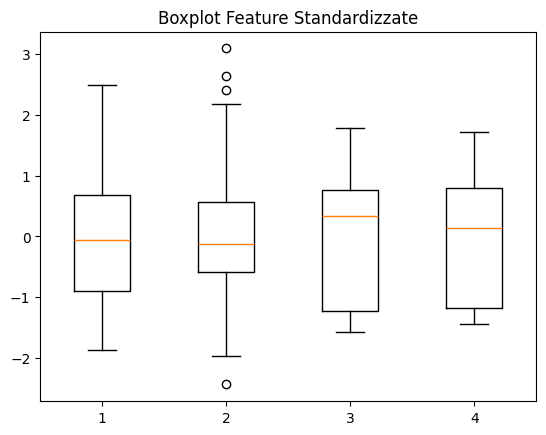

In [9]:
plt.boxplot(X_std)
plt.title("Boxplot Feature Standardizzate")
plt.show()

#PARTE2

In [10]:
eps = 0.45
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_

In [11]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"--- Risultati DBSCAN ---")
print(f"Cluster trovati:\t{n_clusters}")

--- Risultati DBSCAN ---
Cluster trovati:	2


#PARTE3

In [12]:
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X)

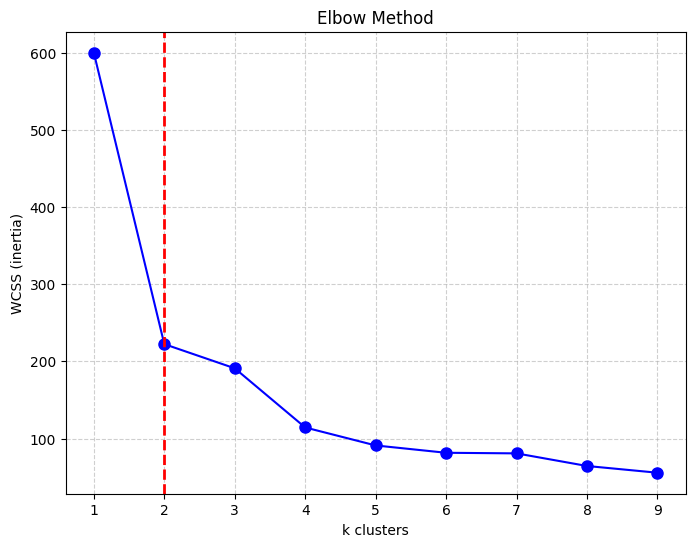

In [15]:
wcss = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, 'o-', color='blue', markersize=8)
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.axvline(x=2, color='red', linestyle='--', linewidth=2, label="Linea verticale")
plt.title("Elbow Method")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [21]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_std)

centroids = kmeans.cluster_centers_
iterations = kmeans.n_iter_

score = silhouette_score(X_std, clusters)
print(score)

0.5817500491982808


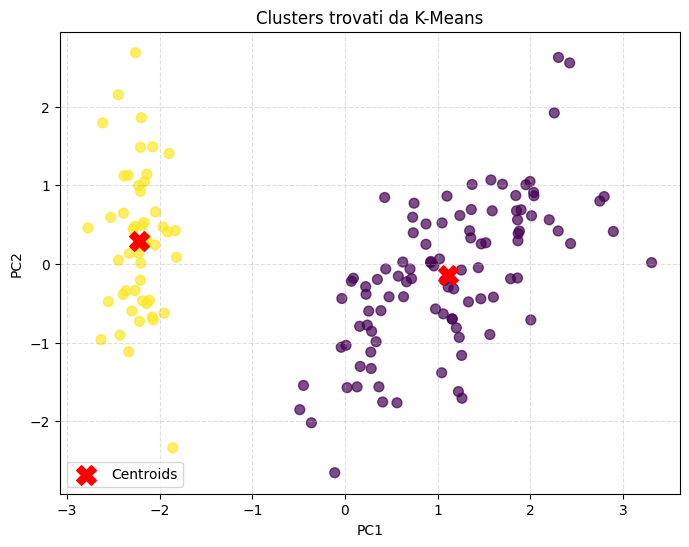

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.scatter(
    pca.transform(centroids)[:, 0],
    pca.transform(centroids)[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)
plt.title("Clusters trovati da K-Means e centroidi")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()